<a href="https://colab.research.google.com/github/FDC-PyArch8/z5688839-PHYS2116-Computational-Assignment/blob/main/z5688839_PHYS2116_computational_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install rebound

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 830.6/830.6 kB 9.4 MB/s eta 0:00:00


In [2]:
import rebound
import math

In [3]:
sim_sun = rebound.Simulation()
sim_sun.units = ('yr', 'AU', 'Msun')
print("G = {0}.".format(sim_sun.G))
sim_sun.add(m=1.0)
sim_sun.add(m=1.0e-3, a=1.0)
sim_sun.integrate(10000)
orbits = sim_sun.orbits()
for o in orbits:
    print(o.a, o.e)

G = 39.476926421373.
0.9999999999999114 1.81309768997835e-13


In [4]:
sim_two_body = rebound.Simulation()
sim_two_body.units = ('yr', 'AU', 'Msun')
print("G = {0}.".format(sim_two_body.G))

sim_two_body.add(m=1.0)
sim_two_body.add(m=1.0, x=1, vy=1)
sim_two_body.status()

sim_two_body.integrate(8000)
sim_two_body.move_to_com()  # setting centre of mass at 0 to reduce numerical error
sim_two_body.status()
orbits = sim_two_body.orbits()
for o in orbits:
    print(o.a, o.e)

G = 39.476926421373.
---------------------------------
REBOUND version:     	4.6.0
REBOUND built on:    	Feb 11 2026 17:35:06
Number of particles: 	2
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x78c79439c650, m=1.0 x=0.0 y=0.0 z=0.0 vx=0.0 vy=0.0 vz=0.0>
<rebound.particle.Particle object at 0x78c79439c8d0, m=1.0 x=1.0 y=0.0 z=0.0 vx=0.0 vy=1.0 vz=0.0>
---------------------------------
The following fields have non-default values:
G:
< 1.000000e+00
---
> 3.947693e+01
N:
< 0
---
> 2
python_unit_l:
< 0
---
> 12937928
python_unit_m:
< 0
---
> 2145773914
python_unit_t:
< 0
---
> 1864791206
rand_seed:
< 573678
---
> 569497
particles:
> (256 bytes, values not printed)

---------------------------------
REBOUND version:     	4.6.0
REBOUND built on:    	Feb 11 2026 17:35:06
Number of particles: 	2
Selected integrator: 	ias15
Simulation time:     	8.0000000000000000

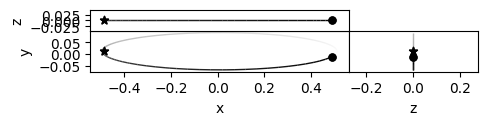

In [5]:
op = rebound.OrbitPlotSet(sim_two_body)

In [6]:
# parsec = au / arcsec
def au(arcsec):
  distance_parsecs = 1.34
  au = distance_parsecs * arcsec
  return au

def radians(degrees):
    return degrees * (math.pi / 180)

In [7]:
au(17.4930)

23.44062

In [8]:
# initialising the simulation and setting a value for G which gives the below units
sim_centauri = rebound.Simulation()
sim_centauri.units = ('yr', 'AU', 'Msun')
print("G = {0}.".format(sim_centauri.G))

# initialising trinary system by adding particles
sim_centauri.add(m=1.0788, hash="cen_a")
sim_centauri.add(m=0.9092, a=23.3, e=0.51947, inc=radians(79.2430),
                 Omega=radians(205.073), omega=radians(231.519), T=1955.564, hash="cen_b")
sim_centauri.add(m=0.122, a=8.2e3, e=0.497, inc=radians(124.9),
                 Omega=radians(165), omega=radians(151.0), T=278e3,
                 hash="prox_cen")
sim_centauri.status()

#references: https://www.mdpi.com/2218-1997/10/2/64,
#            https://iopscience.iop.org/article/10.3847/1538-3881/abfaff/pdf
#            https://www.stellarcatalog.com/stars/proxima-centauri

sim_centauri.integrate(1000)
sim_centauri.move_to_com()  # setting centre of mass at 0 to reduce numerical error
sim_centauri.status()
orbits = sim_centauri.orbits()

G = 39.476926421373.
---------------------------------
REBOUND version:     	4.6.0
REBOUND built on:    	Feb 11 2026 17:35:06
Number of particles: 	3
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x78c7942ef950, m=1.0788 x=0.0 y=0.0 z=0.0 vx=0.0 vy=0.0 vz=0.0>
<rebound.particle.Particle object at 0x78c7942a7750, m=0.9092 x=-18.696523979377055 y=-14.28867265104223 z=26.419040799861133 vx=0.7430779931127516 vy=0.20312296253892428 vz=0.6890830002453935>
<rebound.particle.Particle object at 0x78c7942ef950, m=0.122 x=-10691.342594613147 y=-1304.7679124414537 z=-5748.885259890657 vx=0.3089037306841255 vy=0.12754657943143172 vz=0.35164601179503097>
---------------------------------
The following fields have non-default values:
G:
< 1.000000e+00
---
> 3.947693e+01
N:
< 0
---
> 3
python_unit_l:
< 0
---
> 12937928
python_unit_m:
< 0
---
> 2145773914
python_unit_t:
< 0


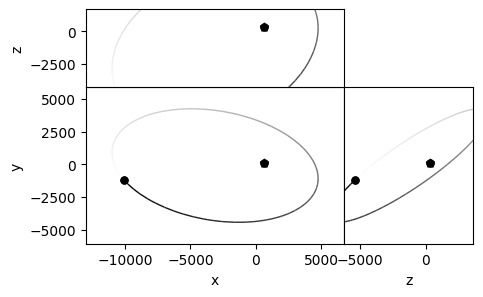

In [9]:
op3 = rebound.OrbitPlotSet(sim_centauri)

NameError: name 'sim' is not defined

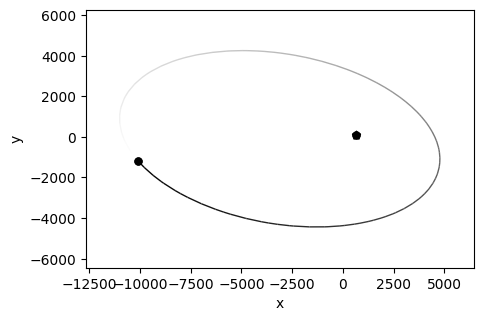

In [10]:
op = rebound.OrbitPlot(sim_centauri)
fig = op.fig
for i in range(3):
    sim.integrate(sim.t+0.31)
    op1.update()
    op2.update()
    op1.fig.savefig("out_%02d.png"%i)
